# Lab 5: personal text2img fine-tuning


## 0. Dependencies

In [ ]:
# %pip uninstall -y torch torchvision torchaudio
# %pip install -U "diffusers>=0.30.0,<0.36.0" "huggingface_hub>=0.24.0,<1.0.0" "transformers>=4.44.0,<5.0.0" "accelerate==0.33.0" "peft>=0.12.0" safetensors pillow "numpy>=1.26,<2.0" "pandas>=2.0,<3.0" scikit-image opencv-python insightface onnxruntime
# %pip install --force-reinstall torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124
# %pip install --force-reinstall "numpy>=1.26,<2.0" "pandas>=2.0,<3.0"

In [1]:
import sys, torch
print(sys.executable)
print(torch.__version__)
print(torch.__file__)
print(torch.version.cuda)
print(torch.cuda.is_available())

C:\Users\Maxim\anaconda3\python.exe
2.6.0+cu124
C:\Users\Maxim\anaconda3\Lib\site-packages\torch\__init__.py
12.4
True


In [2]:
from pathlib import Path
import importlib.metadata as metadata
import importlib.util
import json
import math
import random
import sys
import warnings

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
GENERATED_DIR = OUTPUT_DIR / "generated"
GENERATED_CANDIDATES_DIR = OUTPUT_DIR / "generated_candidates"
METRICS_PATH = OUTPUT_DIR / "metrics.csv"

UNIQUE_TOKEN = "ohwx"

CLASS_WORD = "man"
IDENTITY_DESCRIPTION = "young man with light skin, blue eyes, thick eyebrows, long light brown dreadlocks tied back, sparse mustache and goatee"

BASE_MODEL = "runwayml/stable-diffusion-v1-5"

SEED = 42
IMAGE_SIZE = 512
TRAIN_STEPS = 1000
BATCH_SIZE = 1
LEARNING_RATE = 5e-5
LORA_RANK = 8
FACE_CROP_FOR_TRAINING = True
TRAIN_TOKEN_EMBEDDING = True
MIXED_PRECISION = "bf16"
MAX_GRAD_NORM = 1.0
REQUIRE_CUDA = True
CANDIDATES_PER_PROMPT = 10

TORCH_CUDA_INSTALL_COMMAND = '%pip uninstall -y torch torchvision torchaudio\n%pip install --force-reinstall torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124'
INSTALL_COMMAND = '%pip install -U "diffusers>=0.30.0,<0.36.0" "huggingface_hub>=0.24.0,<1.0.0" "transformers>=4.44.0,<5.0.0" "accelerate==0.33.0" "peft>=0.12.0" safetensors pillow "numpy>=1.26,<2.0" "pandas>=2.0,<3.0" scikit-image opencv-python insightface onnxruntime\n%pip install --force-reinstall torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124\n%pip install --force-reinstall "numpy>=1.26,<2.0" "pandas>=2.0,<3.0"'

OUTPUT_DIR.mkdir(exist_ok=True)
GENERATED_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_CANDIDATES_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)

required_packages = [
    "torch", "torchvision", "diffusers", "transformers", "peft",
    "PIL", "pandas", "skimage", "cv2", "insightface", "onnxruntime",
]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print("Missing packages:", missing)
    print("Run the dependency cell above, then restart the kernel.")
else:
    print("All required packages are available.")

def package_version(name):
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return None

versions = {name: package_version(name) for name in ["diffusers", "huggingface_hub", "transformers", "peft", "torch", "numpy", "pandas"]}
print("Package versions:", versions)

if not missing and importlib.util.find_spec("torch") is not None:
    import torch
    print("Python executable:", sys.executable)
    print("Torch version:", torch.__version__)
    print("Torch module path:", torch.__file__)
    print("Torch CUDA build:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())
    from packaging.version import Version
    torch_base_version = versions["torch"].split("+")[0]
    if Version(torch_base_version) < Version("2.6.0"):
        raise RuntimeError(
            f"Installed torch=={versions['torch']} is too old for the current transformers CLIP loader. "
            "Install CUDA-enabled torch>=2.6, then restart the kernel:\n"
            f"{TORCH_CUDA_INSTALL_COMMAND}"
        )
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print("GPU memory, GiB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
    elif REQUIRE_CUDA:
        raise RuntimeError(
            "PyTorch does not see CUDA, so training would run on CPU. "
            "For RTX 4060 Ti install CUDA-enabled PyTorch, then restart the kernel:\n"
            f"{TORCH_CUDA_INSTALL_COMMAND}\n"
            "If this still fails, check that the NVIDIA driver is installed and that this notebook uses the same environment where PyTorch was installed."
        )

try:
    from packaging.version import Version
    version_rules = {
        "diffusers": (Version("0.30.0"), Version("0.36.0")),
        "huggingface_hub": (Version("0.24.0"), Version("1.0.0")),
        "transformers": (Version("4.44.0"), Version("5.0.0")),
        "numpy": (Version("1.26.0"), Version("2.0.0")),
        "pandas": (Version("2.0.0"), Version("3.0.0")),
    }
    bad_versions = []
    for package, (min_v, max_v) in version_rules.items():
        current = versions.get(package)
        if current and not (min_v <= Version(current) < max_v):
            bad_versions.append(f"{package}=={current} (expected >= {min_v}, < {max_v})")
    if bad_versions:
        raise RuntimeError(
            "Incompatible package versions detected:\n"
            + "\n".join(bad_versions)
            + "\nRun this in the FIRST dependency cell, then restart the kernel:\n"
            + INSTALL_COMMAND
        )
except RuntimeError:
    raise
except Exception as exc:
    warnings.warn(f"Could not check package versions: {exc}")


All required packages are available.
Package versions: {'diffusers': '0.35.2', 'huggingface_hub': '0.36.2', 'transformers': '4.57.6', 'peft': '0.19.1', 'torch': '2.6.0+cu124', 'numpy': '1.26.4', 'pandas': '2.3.3'}
Python executable: C:\Users\Maxim\anaconda3\python.exe
Torch version: 2.6.0+cu124
Torch module path: C:\Users\Maxim\anaconda3\Lib\site-packages\torch\__init__.py
Torch CUDA build: 12.4
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Ti
GPU memory, GiB: 16.0


## 1. Inspect and prepare training photos

Found 15 training photos
self_1.jpeg (827, 1063) RGB
self_10.png (278, 349) RGBA
self_11.png (1280, 853) RGBA
self_12.png (1280, 853) RGBA
self_13.png (1920, 2560) RGBA


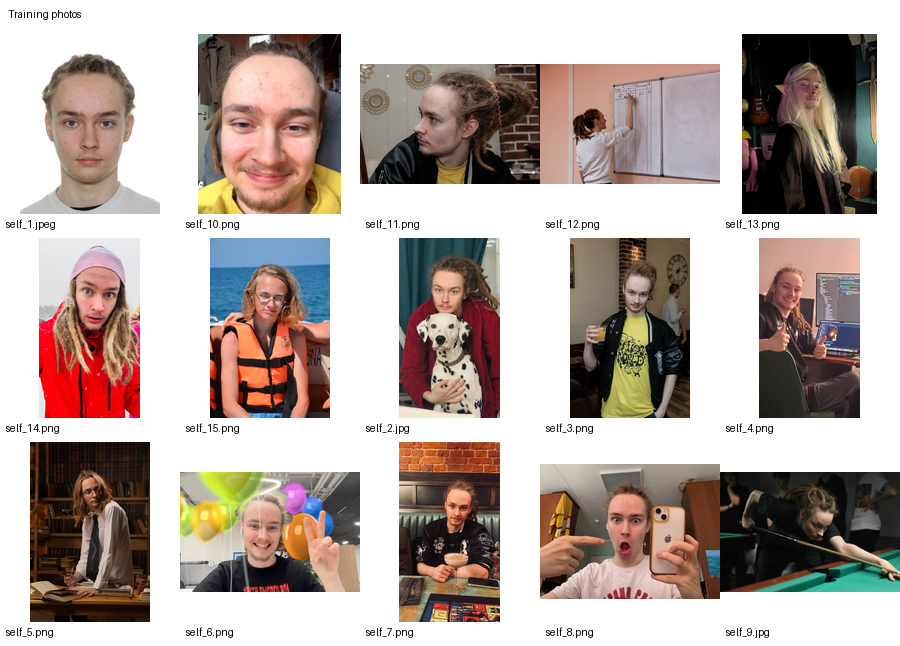

In [3]:
from PIL import Image, ImageOps, ImageDraw
from IPython.display import display

image_paths = sorted(
    [p for p in DATA_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}]
)
assert image_paths, f"No training photos found in {DATA_DIR}"

print(f"Found {len(image_paths)} training photos")
for path in image_paths[:5]:
    with Image.open(path) as img:
        print(path.name, img.size, img.mode)

def make_contact_sheet(paths, labels=None, cols=5, thumb_size=(180, 180), title=None):
    paths = list(paths)
    labels = labels or [Path(p).name for p in paths]
    rows = math.ceil(len(paths) / cols)
    label_h = 24
    title_h = 34 if title else 0
    sheet = Image.new("RGB", (cols * thumb_size[0], rows * (thumb_size[1] + label_h) + title_h), "white")
    draw = ImageDraw.Draw(sheet)
    if title:
        draw.text((8, 8), title, fill="black")
    for i, (path, label) in enumerate(zip(paths, labels)):
        row, col = divmod(i, cols)
        x = col * thumb_size[0]
        y = title_h + row * (thumb_size[1] + label_h)
        img = ImageOps.exif_transpose(Image.open(path)).convert("RGB")
        img.thumbnail(thumb_size, Image.Resampling.LANCZOS)
        paste_x = x + (thumb_size[0] - img.width) // 2
        paste_y = y + (thumb_size[1] - img.height) // 2
        sheet.paste(img, (paste_x, paste_y))
        draw.text((x + 6, y + thumb_size[1] + 4), str(label)[:28], fill="black")
    display(sheet)

make_contact_sheet(image_paths[:15], title="Training photos")


In [4]:
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

def crop_face_or_center(image, margin=0.55):
    """Return a square face-focused crop; fall back to center crop when detection fails."""
    if not FACE_CROP_FOR_TRAINING:
        return image
    rgb = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    detector = cv2.CascadeClassifier(cascade_path)
    faces = detector.detectMultiScale(gray, scaleFactor=1.08, minNeighbors=4, minSize=(60, 60))
    w_img, h_img = image.size
    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda box: box[2] * box[3])
        cx, cy = x + w / 2, y + h / 2
        side = int(max(w, h) * (1 + margin))
    else:
        cx, cy = w_img / 2, h_img / 2
        side = min(w_img, h_img)
    left = max(0, int(cx - side / 2))
    top = max(0, int(cy - side / 2))
    right = min(w_img, left + side)
    bottom = min(h_img, top + side)
    left = max(0, right - side)
    top = max(0, bottom - side)
    return image.crop((left, top, right, bottom))

class PersonalPhotoDataset(Dataset):
    def __init__(self, paths, tokenizer, token, class_word, size=512):
        self.paths = list(paths)
        self.tokenizer = tokenizer
        self.caption = f"close-up portrait photo of {token} {class_word}, {IDENTITY_DESCRIPTION}, realistic face, high quality"
        self.transform = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size),
            transforms.RandomHorizontalFlip(p=0.15),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = ImageOps.exif_transpose(Image.open(self.paths[idx])).convert("RGB")
        image = crop_face_or_center(image)
        input_ids = self.tokenizer(
            self.caption,
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        ).input_ids[0]
        return {"pixel_values": self.transform(image), "input_ids": input_ids}


## 2. Fine-tune text2img with LoRA

In [5]:
import numpy as np
from packaging.version import Version

diffusers_version = metadata.version("diffusers")
if not (Version("0.30.0") <= Version(diffusers_version) < Version("0.36.0")):
    raise RuntimeError(
        "Installed diffusers version is incompatible with this notebook. "
        f"Found diffusers=={diffusers_version}.\n"
        "Run the first dependency cell, restart the kernel, and run the notebook from the beginning. "
        "Expected diffusers >= 0.30.0 and < 0.36.0."
    )

from diffusers import AutoencoderKL, DDPMScheduler, StableDiffusionPipeline, UNet2DConditionModel
from peft import LoraConfig
from transformers import CLIPTextModel, CLIPTokenizer
import torch.nn.functional as F

def train_lora():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if REQUIRE_CUDA and device.type != "cuda":
        raise RuntimeError(
            "CUDA is required, but PyTorch selected CPU. Run the CUDA PyTorch install command, restart the kernel, and try again:\n"
            f"{TORCH_CUDA_INSTALL_COMMAND}"
        )
    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    use_amp = device.type == "cuda" and MIXED_PRECISION in {"fp16", "bf16"}
    amp_dtype = torch.float16 if MIXED_PRECISION == "fp16" else torch.bfloat16
    weight_dtype = torch.float32
    print(f"Training on {device} with dtype={weight_dtype}")

    tokenizer = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder="tokenizer")
    text_encoder = CLIPTextModel.from_pretrained(BASE_MODEL, subfolder="text_encoder").to(device, dtype=weight_dtype)
    token_id = None
    token_embedding = None
    if TRAIN_TOKEN_EMBEDDING:
        added_tokens = tokenizer.add_tokens(UNIQUE_TOKEN)
        if added_tokens == 0:
            print(f"Token {UNIQUE_TOKEN!r} already exists in tokenizer; using existing token id.")
        token_id = tokenizer.convert_tokens_to_ids(UNIQUE_TOKEN)
        initializer_ids = tokenizer.encode(CLASS_WORD, add_special_tokens=False)
        assert initializer_ids, f"Could not tokenize initializer word {CLASS_WORD!r}"
        initializer_id = initializer_ids[0]
        text_encoder.resize_token_embeddings(len(tokenizer))
        token_embedding = text_encoder.get_input_embeddings()
        with torch.no_grad():
            token_embedding.weight[token_id].copy_(token_embedding.weight[initializer_id])
        print(f"Training token embedding: {UNIQUE_TOKEN!r} -> token id {token_id}")
    vae = AutoencoderKL.from_pretrained(BASE_MODEL, subfolder="vae").to(device, dtype=weight_dtype)
    unet = UNet2DConditionModel.from_pretrained(BASE_MODEL, subfolder="unet").to(device, dtype=weight_dtype)
    noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder="scheduler")

    vae.requires_grad_(False)
    text_encoder.requires_grad_(False)
    if TRAIN_TOKEN_EMBEDDING:
        token_embedding.weight.requires_grad_(True)
    unet.requires_grad_(False)

    lora_config = LoraConfig(
        r=LORA_RANK,
        lora_alpha=LORA_RANK,
        init_lora_weights="gaussian",
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    )
    unet.add_adapter(lora_config)
    if hasattr(unet, "enable_gradient_checkpointing"):
        unet.enable_gradient_checkpointing()

    trainable_params = [p for p in unet.parameters() if p.requires_grad]
    if TRAIN_TOKEN_EMBEDDING:
        trainable_params.append(token_embedding.weight)
    optimizer = torch.optim.AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=0.0)
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and MIXED_PRECISION == "fp16"))

    dataset = PersonalPhotoDataset(image_paths, tokenizer, UNIQUE_TOKEN, CLASS_WORD, IMAGE_SIZE)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    vae.eval()
    text_encoder.eval()
    unet.train()

    global_step = 0
    losses = []
    while global_step < TRAIN_STEPS:
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device, dtype=weight_dtype)
            input_ids = batch["input_ids"].to(device)

            with torch.no_grad():
                latents = vae.encode(pixel_values).latent_dist.sample()
                latents = latents * vae.config.scaling_factor
            encoder_hidden_states = text_encoder(input_ids)[0]

            noise = torch.randn_like(latents)
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],), device=device
            ).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
                model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
                target = noise
                loss = F.mse_loss(model_pred.float(), target.float(), reduction="mean")

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss at step {global_step + 1}: {loss.item()}. "
                    "Try MIXED_PRECISION='no' and/or LEARNING_RATE=1e-5."
                )

            scaler.scale(loss).backward()
            if TRAIN_TOKEN_EMBEDDING and token_embedding.weight.grad is not None:
                token_grad_mask = torch.ones(token_embedding.weight.grad.shape[0], dtype=torch.bool, device=device)
                token_grad_mask[token_id] = False
                token_embedding.weight.grad[token_grad_mask] = 0
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            global_step += 1
            losses.append(float(loss.detach().cpu()))
            if global_step % 50 == 0:
                print(f"step {global_step:04d}/{TRAIN_STEPS}, loss={losses[-1]:.4f}")
            if global_step >= TRAIN_STEPS:
                break

    unet.eval()
    pipeline = StableDiffusionPipeline.from_pretrained(
        BASE_MODEL,
        unet=unet,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        vae=vae,
        safety_checker=None,
        torch_dtype=weight_dtype,
    ).to(device)
    pipeline.set_progress_bar_config(disable=False)

    with open(OUTPUT_DIR / "training_losses.json", "w", encoding="utf-8") as f:
        json.dump(losses, f, indent=2)
    return pipeline, losses

pipe, losses = train_lora()
print(f"Training finished. Steps: {len(losses)}, final loss: {losses[-1]:.4f}, best loss: {min(losses):.4f}")
try:
    import pandas as pd
    display(pd.DataFrame({"step": range(1, len(losses) + 1), "loss": losses}).tail(10))
except Exception:
    print("Last losses:", losses[-10:])


Training on cuda with dtype=torch.float32


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Training token embedding: 'ohwx' -> token id 49408


C:\Users\Maxim\AppData\Local\Temp\ipykernel_14060\1898890430.py:74: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and MIXED_PRECISION == "fp16"))


step 0050/1000, loss=0.0568
step 0100/1000, loss=0.0770
step 0150/1000, loss=0.0484
step 0200/1000, loss=0.0122
step 0250/1000, loss=0.0024
step 0300/1000, loss=0.0194
step 0350/1000, loss=0.0121
step 0400/1000, loss=0.9113
step 0450/1000, loss=0.0032
step 0500/1000, loss=0.0544
step 0550/1000, loss=0.1053
step 0600/1000, loss=0.0077
step 0650/1000, loss=0.1461
step 0700/1000, loss=0.0300
step 0750/1000, loss=0.2568
step 0800/1000, loss=0.0243
step 0850/1000, loss=0.2699
step 0900/1000, loss=0.0765
step 0950/1000, loss=0.0028
step 1000/1000, loss=0.4683


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Training finished. Steps: 1000, final loss: 0.4683, best loss: 0.0010


,step,loss
990,991,0.543279
991,992,0.587920
992,993,0.018926
993,994,0.017550
994,995,0.015204
995,996,0.106618
996,997,0.027964
997,998,0.018964
998,999,0.002247
999,1000,0.468264


## 3. Generate required images

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

...

class_forest: selected candidate 0 seed=10042 similarity=nan face_area=nan


  0%|          | 0/45 [00:00<?, ?it/s]

class_city: selected candidate 0 seed=11042 similarity=nan face_area=nan


  0%|          | 0/45 [00:00<?, ?it/s]

class_beach: selected candidate 0 seed=12042 similarity=nan face_area=nan


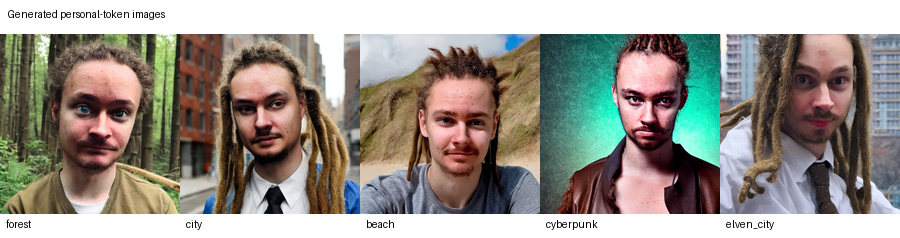

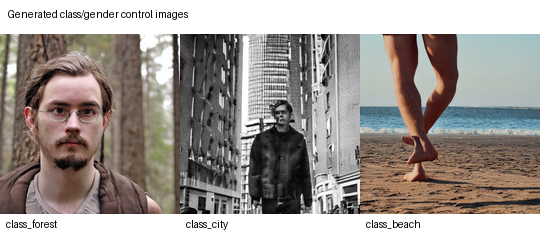

In [7]:
import pandas as pd

personal_prompts = {
    "forest": f"medium close-up environmental portrait photo of {UNIQUE_TOKEN} {CLASS_WORD}, {IDENTITY_DESCRIPTION}, standing in a forest, natural forest background visible behind him, face clearly visible, high quality, realism",
    "city": f"medium close-up environmental portrait photo of {UNIQUE_TOKEN} {CLASS_WORD}, {IDENTITY_DESCRIPTION}, standing on a city street, urban buildings visible behind him, face clearly visible, high quality, realism",
    "beach": f"medium close-up environmental portrait photo of {UNIQUE_TOKEN} {CLASS_WORD}, {IDENTITY_DESCRIPTION}, standing on a beach, ocean and sand visible behind him, face clearly visible, high quality, realism",
    "cyberpunk": f"medium close-up environmental portrait photo of {UNIQUE_TOKEN} {CLASS_WORD}, {IDENTITY_DESCRIPTION}, standing in a cyberpunk neon street, futuristic city background visible behind him, face clearly visible, high quality, realism",
    "elven_city": f"medium close-up environmental portrait photo of {UNIQUE_TOKEN} {CLASS_WORD}, {IDENTITY_DESCRIPTION}, standing in an elven city, fantasy architecture visible behind him, face clearly visible, high quality, realism",
}

class_prompts = {
    "class_forest": f"{CLASS_WORD} in a forest, high quality, realism, portrait photo",
    "class_city": f"{CLASS_WORD} in a city, high quality, realism, portrait photo",
    "class_beach": f"{CLASS_WORD} in a beach, high quality, realism, portrait photo",
}

def load_selection_face_model():
    from insightface.app import FaceAnalysis
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    app = FaceAnalysis(name="buffalo_l", providers=providers)
    app.prepare(ctx_id=0 if torch.cuda.is_available() else -1, det_size=(640, 640))
    return app

def face_embedding_and_area(face_app, image_path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        return None, 0.0
    image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    faces = face_app.get(image)
    if not faces:
        return None, 0.0
    face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
    emb = face.embedding.astype(np.float32)
    emb = emb / np.linalg.norm(emb)
    x1, y1, x2, y2 = face.bbox
    face_area = float(((x2 - x1) * (y2 - y1)) / (image.shape[0] * image.shape[1]))
    return emb, face_area

def build_reference_embedding(face_app):
    embeddings = []
    for path in image_paths:
        emb, _ = face_embedding_and_area(face_app, path)
        if emb is not None:
            embeddings.append(emb)
    assert embeddings, "No faces were detected in source photos."
    ref = np.mean(embeddings, axis=0)
    return ref / np.linalg.norm(ref)

def cosine_np(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def selection_score(face_similarity, face_area):
    if not np.isfinite(face_similarity):
        return -1.0
    area_penalty = abs(face_area - 0.22) * 0.8
    return face_similarity - area_penalty

@torch.inference_mode()
def generate_best_of_n(pipe, prompts, seed=SEED, steps=45, guidance_scale=5.2, candidates_per_prompt=CANDIDATES_PER_PROMPT, select_by_identity=True):
    saved = []
    selection_rows = []
    face_app = load_selection_face_model() if select_by_identity else None
    reference_embedding = build_reference_embedding(face_app) if select_by_identity else None

    for prompt_index, (name, prompt) in enumerate(prompts.items()):
        best = None
        best_row = None
        for candidate_idx in range(candidates_per_prompt):
            candidate_seed = seed + prompt_index * 1000 + candidate_idx
            generator = torch.Generator(device=pipe.device).manual_seed(candidate_seed)
            image = pipe(
                prompt=prompt,
                num_inference_steps=steps,
                guidance_scale=guidance_scale,
                generator=generator,
                height=IMAGE_SIZE,
                width=IMAGE_SIZE,
            ).images[0]
            candidate_path = GENERATED_CANDIDATES_DIR / f"{name}_{candidate_idx:02d}.png"
            image.save(candidate_path)

            face_similarity = np.nan
            face_area = np.nan
            score = 0.0
            if select_by_identity:
                emb, face_area = face_embedding_and_area(face_app, candidate_path)
                if emb is not None:
                    face_similarity = cosine_np(emb, reference_embedding)
                score = selection_score(face_similarity, face_area)

            row = {
                "name": name,
                "candidate": candidate_idx,
                "seed": candidate_seed,
                "prompt": prompt,
                "path": str(candidate_path),
                "face_similarity": face_similarity,
                "face_area": face_area,
                "selection_score": score,
            }
            selection_rows.append(row)
            if best is None or row["selection_score"] > best_row["selection_score"]:
                best = image
                best_row = row

        final_path = GENERATED_DIR / f"{name}.png"
        best.save(final_path)
        print(f"{name}: selected candidate {best_row['candidate']} seed={best_row['seed']} similarity={best_row['face_similarity']:.3f} face_area={best_row['face_area']:.3f}")
        saved.append((name, prompt, final_path))

    selection_table = pd.DataFrame(selection_rows)
    selection_table.to_csv(OUTPUT_DIR / "generation_selection.csv", index=False)
    return saved, selection_table

generated_personal, personal_selection = generate_best_of_n(pipe, personal_prompts, select_by_identity=True)
generated_class, class_selection = generate_best_of_n(pipe, class_prompts, seed=SEED + 10000, candidates_per_prompt=1, select_by_identity=False)
all_generated = generated_personal + generated_class

def show_grid(items, title):
    paths = [path for name, prompt, path in items]
    labels = [name for name, prompt, path in items]
    make_contact_sheet(paths, labels=labels, cols=min(5, len(items)), title=title)

show_grid(generated_personal, "Generated personal-token images")
show_grid(generated_class, "Generated class/gender control images")


## 4. Evaluate with three non-FID/IS metrics

In [8]:
import cv2
import numpy as np
import pandas as pd
from skimage.measure import shannon_entropy
from transformers import CLIPModel, CLIPProcessor

def technical_quality(path):
    image = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    contrast = float(gray.std())
    entropy = float(shannon_entropy(gray))

    sharpness_score = min(sharpness / 900.0, 1.0)
    contrast_score = min(contrast / 70.0, 1.0)
    entropy_score = min(entropy / 8.0, 1.0)
    quality = 0.45 * sharpness_score + 0.30 * contrast_score + 0.25 * entropy_score
    return {
        "sharpness": sharpness,
        "contrast": contrast,
        "entropy": entropy,
        "technical_quality": quality,
    }

def load_face_model():
    from insightface.app import FaceAnalysis
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    app = FaceAnalysis(name="buffalo_l", providers=providers)
    app.prepare(ctx_id=0 if torch.cuda.is_available() else -1, det_size=(640, 640))
    return app

def largest_face_embedding(face_app, path):
    image = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    faces = face_app.get(image)
    if not faces:
        return None
    face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
    emb = face.embedding.astype(np.float32)
    return emb / np.linalg.norm(emb)

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

face_app = load_face_model()
source_embeddings = [largest_face_embedding(face_app, p) for p in image_paths]
source_embeddings = [e for e in source_embeddings if e is not None]
assert source_embeddings, "No faces were detected in source photos. Check the input images."
mean_source_embedding = np.mean(source_embeddings, axis=0)
mean_source_embedding = mean_source_embedding / np.linalg.norm(mean_source_embedding)

clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name).to(pipe.device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

@torch.inference_mode()
def clip_similarity(path, prompt):
    image = Image.open(path).convert("RGB")
    inputs = clip_processor(text=[prompt], images=[image], return_tensors="pt", padding=True).to(pipe.device)
    outputs = clip_model(**inputs)
    image_emb = outputs.image_embeds / outputs.image_embeds.norm(dim=-1, keepdim=True)
    text_emb = outputs.text_embeds / outputs.text_embeds.norm(dim=-1, keepdim=True)
    return float((image_emb * text_emb).sum().detach().cpu())

rows = []
for name, prompt, path in all_generated:
    face_embedding = largest_face_embedding(face_app, path)
    face_score = cosine(face_embedding, mean_source_embedding) if face_embedding is not None else np.nan
    row = {
        "name": name,
        "prompt": prompt,
        "path": str(path),
        "face_similarity": face_score,
        "clip_prompt_similarity": clip_similarity(path, prompt),
    }
    row.update(technical_quality(path))
    rows.append(row)

metrics = pd.DataFrame(rows)
metrics.to_csv(METRICS_PATH, index=False)
metrics


C:\Users\Maxim\anaconda3\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Maxim/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112] 127.

C:\Users\Maxim\anaconda3\Lib\site-packages\insightface\utils\transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4
C:\Users\Maxim\anaconda3\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor wit

,name,prompt,path,face_similarity,clip_prompt_similarity,sharpness,contrast,entropy,technical_quality
0,forest,medium close-up environmental portrait photo o...,C:\Users\Maxim\study\computer-vision\lab5\outp...,0.459254,0.348702,266.341904,55.350896,7.729071,0.611923
1,city,medium close-up environmental portrait photo o...,C:\Users\Maxim\study\computer-vision\lab5\outp...,0.426366,0.369190,283.773093,64.984048,7.808206,0.664396
2,beach,medium close-up environmental portrait photo o...,C:\Users\Maxim\study\computer-vision\lab5\outp...,0.522985,0.370321,436.029729,57.528696,7.719303,0.705795
3,cyberpunk,medium close-up environmental portrait photo o...,C:\Users\Maxim\study\computer-vision\lab5\outp...,0.546533,0.343346,1196.272836,66.910257,7.835999,0.981633
4,elven_city,medium close-up environmental portrait photo o...,C:\Users\Maxim\study\computer-vision\lab5\outp...,0.438584,0.360088,344.104651,56.390529,7.714214,0.654795
5,class_forest,"man in a forest, high quality, realism, portra...",C:\Users\Maxim\study\computer-vision\lab5\outp...,0.256032,0.317440,426.944134,48.385916,7.509989,0.655527
6,class_city,"man in a city, high quality, realism, portrait...",C:\Users\Maxim\study\computer-vision\lab5\outp...,0.064267,0.285788,1502.951066,69.083088,7.907118,0.993168
7,class_beach,"man in a beach, high quality, realism, portrai...",C:\Users\Maxim\study\computer-vision\lab5\outp...,NaN,0.283674,1113.961109,53.835729,7.126862,0.903439


In [9]:
summary = metrics[["face_similarity", "clip_prompt_similarity", "technical_quality"]].describe().T
display(summary)

personal_metrics = metrics[metrics["name"].isin(personal_prompts.keys())]
print("Personal-token image averages:")
display(personal_metrics[["face_similarity", "clip_prompt_similarity", "technical_quality"]].mean())

best = personal_metrics.sort_values(
    ["face_similarity", "clip_prompt_similarity", "technical_quality"],
    ascending=False,
).head(5)
print("Best personal-token outputs by identity, prompt alignment, and quality:")
display(best[["name", "face_similarity", "clip_prompt_similarity", "technical_quality", "path"]])


,count,mean,std,min,25%,50%,75%,max
face_similarity,7.0,0.387717,0.170626,0.064267,0.341199,0.438584,0.491119,0.546533
clip_prompt_similarity,8.0,0.334819,0.035188,0.283674,0.309527,0.346024,0.362363,0.370321
technical_quality,8.0,0.771334,0.159921,0.611923,0.655344,0.685095,0.922988,0.993168


Personal-token image averages:


face_similarity           0.478744
clip_prompt_similarity    0.358329
technical_quality         0.723708
dtype: float64

Best personal-token outputs by identity, prompt alignment, and quality:


,name,face_similarity,clip_prompt_similarity,technical_quality,path
3,cyberpunk,0.546533,0.343346,0.981633,C:\Users\Maxim\study\computer-vision\lab5\outp...
2,beach,0.522985,0.370321,0.705795,C:\Users\Maxim\study\computer-vision\lab5\outp...
0,forest,0.459254,0.348702,0.611923,C:\Users\Maxim\study\computer-vision\lab5\outp...
4,elven_city,0.438584,0.360088,0.654795,C:\Users\Maxim\study\computer-vision\lab5\outp...
1,city,0.426366,0.369190,0.664396,C:\Users\Maxim\study\computer-vision\lab5\outp...
